In [12]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'malcolmX@1974',
    database = 'purchases')

cur = conn.cursor()



# List all unique cities where customers are located.

In [2]:
cur = conn.cursor()

query = """ select distinct City from salless """

df = pd.read_sql(query, conn)

cur.execute(query)

data = cur.fetchall()

data


C:\Users\USER\AppData\Local\Temp\ipykernel_16076\4253561879.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


[('Henderson',),
 ('Los Angeles',),
 ('Fort Lauderdale',),
 ('Concord',),
 ('Seattle',),
 ('Fort Worth',),
 ('Madison',),
 ('West Jordan',),
 ('San Francisco',),
 ('Fremont',),
 ('Philadelphia',),
 ('Orem',),
 ('Houston',),
 ('Richardson',),
 ('Naperville',),
 ('Melbourne',),
 ('Eagan',),
 ('Westland',),
 ('Dover',),
 ('New Albany',),
 ('New York City',),
 ('Troy',),
 ('Chicago',),
 ('Gilbert',),
 ('Springfield',),
 ('Jackson',),
 ('Memphis',),
 ('Decatur',),
 ('Durham',),
 ('Columbia',),
 ('Rochester',),
 ('Minneapolis',),
 ('Portland',),
 ('Saint Paul',),
 ('Aurora',),
 ('Charlotte',),
 ('Orland Park',),
 ('Urbandale',),
 ('Columbus',),
 ('Bristol',),
 ('Wilmington',),
 ('Bloomington',),
 ('Phoenix',),
 ('Roseville',),
 ('Independence',),
 ('Pasadena',),
 ('Newark',),
 ('Franklin',),
 ('Scottsdale',),
 ('San Jose',),
 ('Edmond',),
 ('Carlsbad',),
 ('San Antonio',),
 ('Monroe',),
 ('Fairfield',),
 ('Grand Prairie',),
 ('Redlands',),
 ('Hamilton',),
 ('Westfield',),
 ('Akron',),
 ('Den

# Count the number of orders placed in 2015.

In [38]:
cur = conn.cursor()

query = """ select count(order_id) from sales where year(order_date) = 2015 """

cur.execute(query)

data = cur.fetchall()

"Total number of sales in 2015 are", data[0][0]

('Total number of sales in 2015 are', 2102)

# Find the total sales per category

In [35]:
cur = conn.cursor()

query = """ SELECT upper(`Sub-Category`), round(sum(Sales),3) as total_sales_per_category FROM purchases.saless
group by `Sub-Category`
order by total_sales_per_category desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])

df


,Category,Sales
0,PHONES,330007.054
1,CHAIRS,328449.103
2,STORAGE,223843.608
3,TABLES,206965.532
4,BINDERS,203412.733
5,MACHINES,189238.631
6,ACCESSORIES,167380.318
7,COPIERS,149528.030
8,BOOKCASES,114879.996
9,APPLIANCES,107532.161


 # Count the number of customers from each state. 


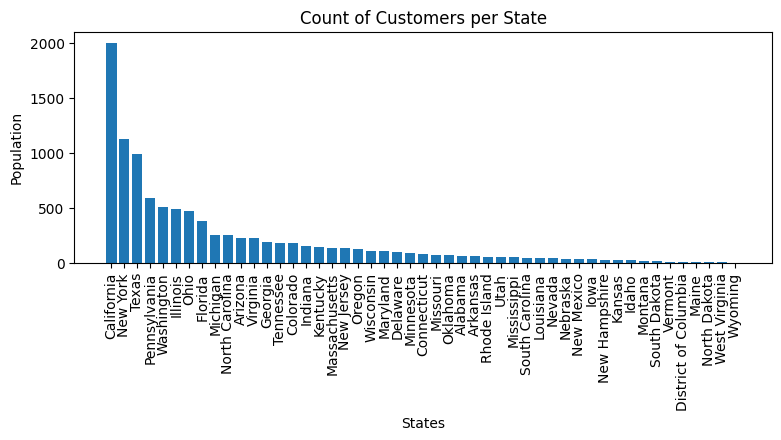

In [5]:
cur = conn.cursor()

query = """ SELECT State, count(State) as total_customers_per_state FROM purchases.saless
group by State
order by total_customers_per_state desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["State", "Population"])

plt.figure(figsize = (9,3))
plt.bar(df["State"], df["Population"])
plt.xticks(rotation = 90)
plt.xlabel("States")
plt.ylabel("Population")
plt.title("Count of Customers per State")
plt.show()




# Calculate the number of orders per month in 2018

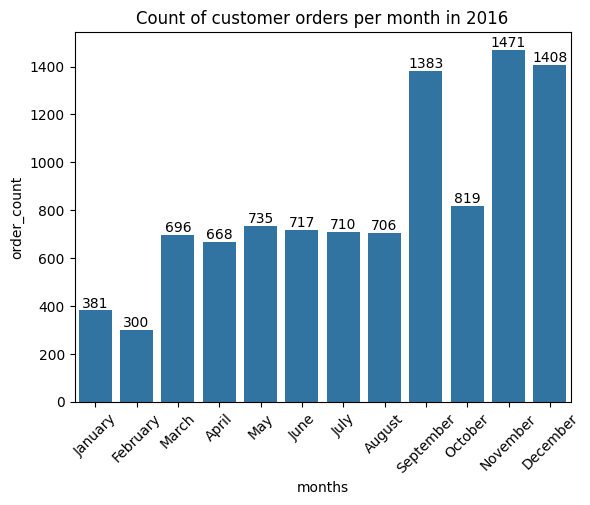

In [6]:
cur = conn.cursor()
query = """ select monthname(order_date) as months, count(order_id) as order_count from purchases.sales
group by months
order by order_count desc """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])

b = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = b)

plt.xticks(rotation = 45)
plt.title("Count of customer orders per month in 2016")
ax.bar_label(ax.containers[0])
plt.show()

# Find the average number of products per order, grouped by customer city

In [7]:
cur = conn.cursor()
query = """ select City, round(avg(total_order), 2) as avg_products_per_order from (
select City, order_id, sum(Quantity) as total_order from purchases.saless
group by City, order_id
) as sub
group by City
order by avg_products_per_order desc;
#SELECT City, round(avg(quantity), 2) as average_orders FROM purchases.saless
#group by City
#order by average_orders desc """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["City" , "Average Order"])
df.head(11)

,City,Average Order
0,South Bend,25.00
1,Passaic,24.00
2,Eugene,23.00
3,Logan,21.00
4,Danville,19.00
5,Superior,18.50
6,Carol Stream,18.00
7,Lakeville,16.80
8,Gastonia,16.00
9,Morgan Hill,16.00


# Calculate the percentage of total revenue contributed by each product category

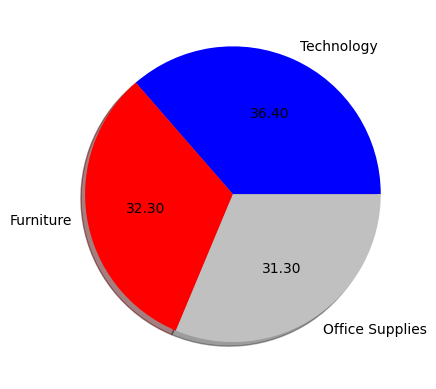

In [34]:
cur = conn.cursor()

cur.execute(query)

query = """ select Category, round((sum(Sales)/(select sum(Sales) from purchases.saless))* 100, 2) 
as sales_percentage from purchases.saless
group by Category
order by sales_percentage desc """

data = cur.fetchall()


df = pd.DataFrame(data, columns = ["Category", "percentage distribution"])


c = ["blue", "red", "silver"]
ex = [0,0,0,0.1,0]
plt.pie(df["percentage distribution"], labels = df["Category"], autopct = "%.2f", colors = c, shadow = True)
plt.show()

# Identify the correlation between product price and the number of times a product has been purchased.


In [15]:
cur = conn.cursor()
query = """ select upper(`Sub-Category`),count(product_id), round(avg(Sales * Quantity), 2) from purchases.saless
group by `Sub-Category` """

cur.execute(query)
data = cur.fetchall()
data
df = pd.DataFrame(data, columns = ["Sub-Category", "Product count", "Average Price"])

arr1 = df["Product count"]
arr2 = df["Average Price"]
a = np.corrcoef([arr1, arr2])

print("The correlation between product price and the number of times a product has been purchased is", a[0][1])

The correlation between product price and the number of times a product has been purchased is -0.48125731648504894


# Calculate the total revenue generated by each seller, and rank them by revenue.


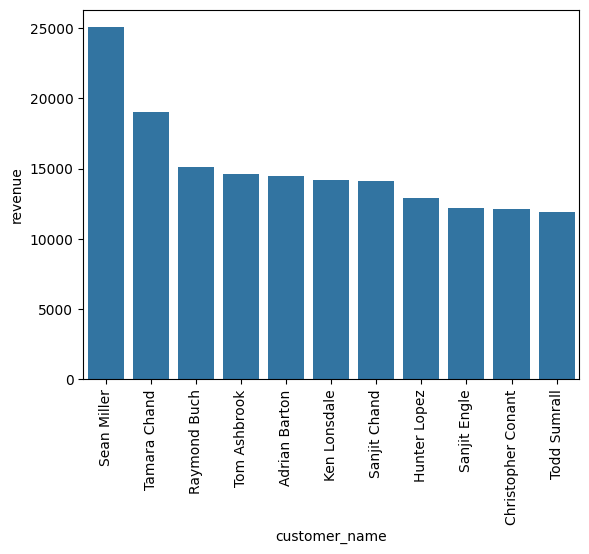

In [32]:
cur = conn.cursor()
query = """ select * , dense_rank() over(order by revenue_generated desc) as rn from 
(SELECT customer_name, round(sum(Sales), 2) as revenue_generated FROM purchases.saless
group by customer_name
order by revenue_generated desc) as a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_name", "revenue", "rank"])
df = df.head(11)
sns.barplot(x = "customer_name", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.


In [28]:
cur = conn.cursor()
query = """ select customer_id, order_date, payment,
round(avg(payment) over(partition by customer_id order by order_date
rows between 2 preceding and current row), 2) as mov_avg
from 
(select customer_id, order_date, 
Sales as payment from purchases.sales) as a """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["customer_id", "order_date", "payment", "moving_average"])
df

,customer_id,order_date,payment,moving_average
0,AA-10315,2014-03-31,52.980,52.98
1,AA-10315,2014-03-31,673.568,363.27
2,AA-10315,2014-09-15,14.940,247.16
3,AA-10315,2014-09-15,14.560,234.36
4,AA-10315,2015-10-04,26.960,18.82
...,...,...,...,...
9989,ZD-21925,2016-04-03,259.960,117.93
9990,ZD-21925,2016-05-05,16.720,115.93
9991,ZD-21925,2016-07-08,15.984,97.55
9992,ZD-21925,2016-07-08,823.960,285.55


# Calculate the cumulative sales per month for each year

In [27]:
cur = conn.cursor()
query = """ select years, months, payment, round(sum(payment)
over(order by years, months), 2) as culmulative_sales
from
(select year(order_date) as years,
month(order_date) as months,
round(sum(Sales), 2) as payment from purchases.sales
group by years, months order by years, months) as a """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["years", "months", "payment", "culmulative sales"])
df

,years,months,payment,culmulative sales
0,2014,1,14236.89,14236.89
1,2014,2,4519.89,18756.78
2,2014,3,55691.01,74447.79
3,2014,4,28295.34,102743.13
4,2014,5,23648.29,126391.42
5,2014,6,34595.13,160986.55
6,2014,7,33946.39,194932.94
7,2014,8,27909.47,222842.41
8,2014,9,81777.35,304619.76
9,2014,10,31453.39,336073.15


# Calculate the year-over-year growth rate of total sales

In [26]:
cur = conn.cursor()
query = """with a as(select year(order_date) as years,
round(sum(`Sales`), 2) as payment from purchases.sales
group by years order by years) 

select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)) * 100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "% growth rate"])
df

,years,% growth rate
0,2014,NaN
1,2015,-2.832227
2,2016,29.471522
3,2017,20.355962


# Identify the top 3 customers who spent the most money in each year.

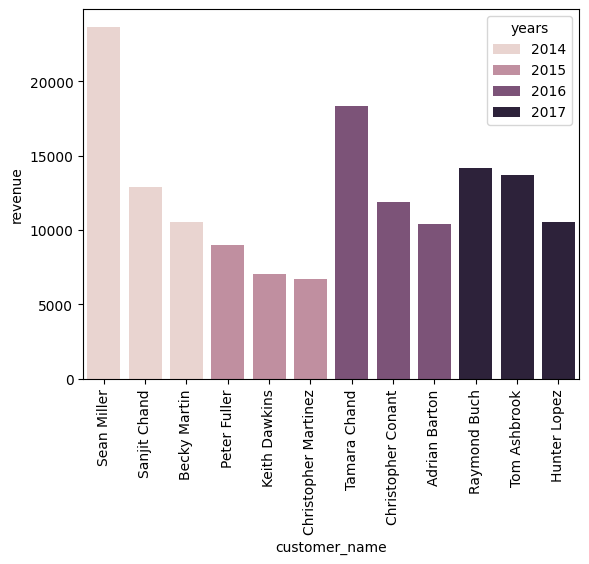

In [25]:
cur = conn.cursor()
query = """ select years, customer_name, payment, d_rank
from
(select year(order_date) as years, customer_name, round(sum(Sales), 2) as payment,
dense_rank() over(partition by year(order_date) order by sum(Sales) desc) d_rank from purchases.sales
group by year(order_date), customer_name) as a
where d_rank <= 3 """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "customer_name", "revenue", "rank"])
sns.barplot(x = "customer_name", y = "revenue", data = df, hue = "years")
plt.xticks(rotation =90)
plt.show()